# Блок 4 • Занятие 5 — доверительные интервалы и бутстрэп (bootstrap CI) (TODO)
**Дата:** 2026-03-02  
**Формат:** мини-теория → 10 кодовых ячеек → автопроверка (`assert`) → Run all  
**Цель занятия:** уметь строить **доверительный интервал** для среднего и понимать идею **бутстрэпа** как “пересэмплирования” выборки.

---

## Мини-теория (термины, особенности, синтаксис)

### 1) Оценка и доверительный интервал
- **Точечная оценка** — одно число (например, среднее по выборке).
- **Доверительный интервал (CI)** — диапазон, который “часто” содержит истинное значение параметра.
  - Пример: 95% CI для среднего.

Важно: 95% CI **не означает**, что вероятность истинного среднего “95%”.  
Правильно: если повторять сбор выборки и строить интервалы, то **примерно 95% интервалов** накроют истинное значение.

### 2) Стандартная ошибка среднего (SEM)
Если `std` — стандартное отклонение, `n` — размер выборки:
- **SEM = std / sqrt(n)**

### 3) Быстрый (приближённый) CI для среднего
Для учебных целей используем приближение (для больших n):
- 95% CI ≈ mean ± 1.96 * SEM  
(мы не углубляемся в t-распределение — это будет позже / опционально)

### 4) Бутстрэп (bootstrap)
**Бутстрэп** — это симуляция:  
мы много раз берём “новую выборку” из исходной **с возвращением** и считаем среднее.
Дальше берём квантили (например, 2.5% и 97.5%) — это и есть bootstrap CI.

### 5) Где это в дипломе
- показать “насколько стабильна” оценка качества (точность/среднее время/метрика)
- оценить неопределённость результата

---

## Задача урока (перенос в VS Code)
Перенесите в проект:
- `src/math_stats.py`: `mean`, `std_sample`, `ci_mean_normal_approx`, `bootstrap_ci_mean`
- (опционально) `src/plots.py`: `plot_bootstrap_hist`


---
## Ячейка 1/10 — Данные: создаём выборку (numpy) и фиксируем seed

**Зачем seed**
- Чтобы результаты были повторяемыми (важно для обучения и тестов).

**Функции**
- `np.random.default_rng(seed)` — генератор случайных чисел
- `rng.normal(loc, scale, size)` — нормальное распределение


In [10]:
import numpy as np

# TODO: создайте rng с seed=42 и сгенерируйте data: normal(loc=10, scale=2, size=50)
rng = np.random.default_rng(42)
data = rng.normal(loc=10.0, scale=2.0, size=50)
len(data), float(data[0])


(50, 10.609434159508863)

---
## Ячейка 2/10 — Функция `mean` (без pandas)

**Синтаксис**
- `def ...` — объявление функции
- `return` — вернуть значение

**Зачем не использовать np.mean?**
В дипломе бывает нужно писать “свои” функции и тестировать их.


In [11]:
def mean(values) -> float:
    """Среднее арифметическое для списка/массива."""
    # TODO: проверьте пустой список и верните sum(values)/len(values)
    if len(values) == 0:
        raise ValueError("mean: empty")
    return float(sum(values)) / len(values)

m = mean(data)
m


10.182422060986022

---
## Ячейка 3/10 — Выборочное std: `std_sample`

**Термины**
- дисперсия (sample variance) делится на `n-1`
- стандартное отклонение = sqrt(variance)

**Синтаксис**
- генератор: `sum((x-m)**2 for x in values)`


In [12]:
def variance_sample(values) -> float:
    # TODO: реализуйте выборочную дисперсию: sum((x-m)^2)/(n-1)
    n = len(values)
    if n < 2:
        raise ValueError("variance_sample: need >=2")
    m = mean(values)
    return float(sum((x - m) ** 2 for x in values)) / (n - 1)

def std_sample(values) -> float:
    # TODO: верните sqrt(variance_sample(values))
    return variance_sample(values) ** 0.5

s = std_sample(data)
s


1.5365544567151899

---
## Ячейка 4/10 — Стандартная ошибка среднего (SEM)

**Формула**
SEM = std / sqrt(n)

**Зачем**
SEM показывает “насколько дрожит” среднее как оценка.


In [13]:
def sem(values) -> float:
    # TODO: реализуйте SEM = std_sample(values)/sqrt(n)
    n = len(values)
    if n <= 0:
        raise ValueError("sem: empty")
    return std_sample(values) / (n ** 0.5)

sem_val = sem(data)
sem_val


0.21730161520114444

---
## Ячейка 5/10 — Приближённый 95% CI для среднего (normal approx)

**Формула**
CI95 ≈ mean ± 1.96 * SEM

**Особенность**
Это приближение. Для небольших n точнее использовать t-распределение,
но для этого курса на данном этапе достаточно приближения + бутстрэпа.


In [14]:
def ci_mean_normal_approx(values, z: float = 1.96):
    """Приближённый CI для среднего: mean ± z*SEM."""
    # TODO: посчитайте m=mean(values), se=sem(values) и верните (m - z*se, m + z*se)
    m = mean(values)
    se = sem(values)
    return (m - z * se, m + z * se)

ci_norm = ci_mean_normal_approx(data)
ci_norm


(9.756510895191779, 10.608333226780266)

---
## Ячейка 6/10 — Бутстрэп: “новая выборка из старой” с возвращением

**Идея**
- Выбираем `n` элементов из данных **с возвращением**
- Считаем среднее
- Повторяем много раз

**Функции numpy**
- `rng.integers(0, n, size=n)` — индексы для ресэмплинга


In [15]:
def bootstrap_means(values, n_boot: int = 2000, seed: int = 0):
    # TODO: реализуйте список из n_boot средних, полученных бутстрэпом
    rng = np.random.default_rng(seed)
    values = np.asarray(values)
    n = len(values)
    if n == 0:
        raise ValueError("bootstrap_means: empty")
    means = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        sample_b = values[idx]
        means.append(float(np.mean(sample_b)))
    return means

boot = bootstrap_means(data, n_boot=2000, seed=1)
len(boot), boot[0]


(2000, 10.023833906811042)

---
## Ячейка 7/10 — Bootstrap CI через квантили

Для 95% CI берём:
- нижний квантиль 2.5%
- верхний квантиль 97.5%

**Функции**
- `np.quantile(array, q)`


In [16]:
def bootstrap_ci_mean(values, n_boot: int = 2000, alpha: float = 0.05, seed: int = 0):
    # TODO: получите means=bootstrap_means(...), верните квантили (alpha/2, 1-alpha/2)
    means = bootstrap_means(values, n_boot=n_boot, seed=seed)
    low = float(np.quantile(means, alpha/2))
    high = float(np.quantile(means, 1 - alpha/2))
    return low, high

ci_boot = bootstrap_ci_mean(data, n_boot=2000, alpha=0.05, seed=1)
ci_boot


(9.759795234137963, 10.57004527743477)

---
## Ячейка 8/10 — График: распределение бутстрэп-средних + линии CI (matplotlib)

**Что на графике**
- гистограмма бутстрэп-средних
- вертикальные линии: mean, CI_low, CI_high

Это наглядно показывает неопределённость средней оценки.


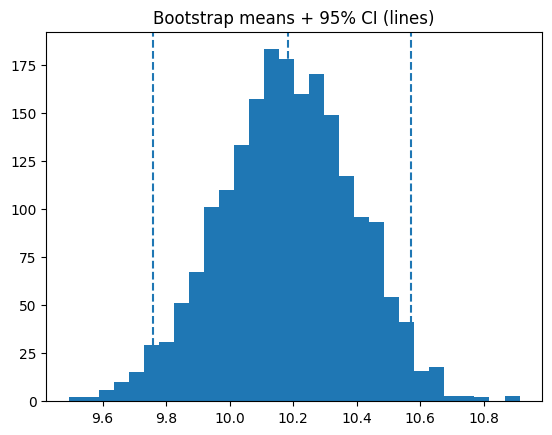

mean = 10.182
bootstrap CI = (9.76, 10.57)


In [17]:
import matplotlib.pyplot as plt

# TODO: постройте гистограмму boot (из ячейки 6) и нанесите 3 вертикальные линии: mean(data), ci_boot[0], ci_boot[1]
boot_means = boot
ci_low, ci_high = ci_boot
m_hat = mean(data)

plt.hist(boot_means, bins=30)
plt.axvline(m_hat, linestyle="--")
plt.axvline(ci_low, linestyle="--")
plt.axvline(ci_high, linestyle="--")
plt.title("Bootstrap means + 95% CI (lines)")
plt.show()

print("mean =", round(m_hat, 3))
print("bootstrap CI =", (round(ci_low, 3), round(ci_high, 3)))


---
## Ячейка 9/10 — Эксперимент: как размер выборки влияет на ширину CI (matplotlib)

**Идея**
Если данных больше, среднее оценивается точнее → CI становится уже.

Мы сравним bootstrap CI для n=20 и n=200 (на синтетике).


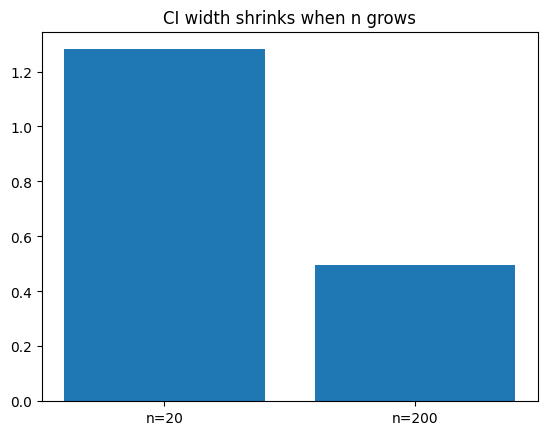

width n=20  = 1.281
width n=200 = 0.494


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: создайте data20 и data200, посчитайте ci20 и ci200, ширины width20/width200 и постройте bar chart
rng = np.random.default_rng(7)

data20 = rng.normal(10.0, 2.0, 20)
data200 = rng.normal(10.0, 2.0, 200)

ci20 = bootstrap_ci_mean(data20, n_boot=1500, seed=2)
ci200 = bootstrap_ci_mean(data200, n_boot=1500, seed=2)

width20 = ci20[1] - ci20[0]
width200 = ci200[1] - ci200[0]

plt.bar(["n=20", "n=200"], [width20, width200])
plt.title("CI width shrinks when n grows")
plt.show()

print("width n=20  =", round(width20, 3))
print("width n=200 =", round(width200, 3))


---
## Ячейка 10/10 — Автопроверка (`assert`)

Тесты проверяют:
- среднее/стандартное отклонение
- нормальный CI (ширина > 0)
- bootstrap CI (low < mean < high)
- CI с большим n обычно уже, чем с маленьким n

Run all.


In [19]:
# =========================
# BLOCK 04 — LESSON 05 TESTS (НЕ МЕНЯТЬ)
# =========================

def approx(a: float, b: float, eps: float = 1e-6) -> bool:
    return abs(a - b) <= eps

def run_all_tests():
    import numpy as np
    rng = np.random.default_rng(42)
    d = rng.normal(10.0, 2.0, 50)

    m = mean(d)
    s = std_sample(d)
    assert 8.0 < m < 12.0
    assert s > 0.0

    low, high = ci_mean_normal_approx(d)
    assert low < high
    assert low < m < high  # обычно так (синтетика)

    ci_b = bootstrap_ci_mean(d, n_boot=1000, seed=1)
    assert ci_b[0] < ci_b[1]
    assert ci_b[0] < m < ci_b[1]

    rng2 = np.random.default_rng(7)
    d20 = rng2.normal(10.0, 2.0, 20)
    d200 = rng2.normal(10.0, 2.0, 200)
    ci20 = bootstrap_ci_mean(d20, n_boot=800, seed=2)
    ci200 = bootstrap_ci_mean(d200, n_boot=800, seed=2)
    w20 = ci20[1] - ci20[0]
    w200 = ci200[1] - ci200[0]
    assert w20 > 0 and w200 > 0
    assert w200 < w20  # чаще всего так

    print("✅ BLOCK04 LESSON05: all tests passed")

run_all_tests()


✅ BLOCK04 LESSON05: all tests passed
